In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer

In [3]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [4]:
df = pd.read_csv("product_feedback_dataset.csv")
df.head()

,Feedback_ID,Product,Feedback,Rating,Category
0,1,Wireless Headphones,The sound quality is excellent and the battery...,5,Product Quality
1,2,Wireless Headphones,The headphones are comfortable but the price i...,3,Pricing
2,3,Wireless Headphones,The packaging was damaged when I received the ...,2,Packaging
3,4,Wireless Headphones,Very easy to connect and use with my phone.,5,Usability
4,5,Wireless Headphones,The audio is poor and there is too much backgr...,2,Product Quality


In [5]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns)

print("\nDataset information:")
df.info()

Number of rows: 40
Number of columns: 5

Column names:
Index(['Feedback_ID', 'Product', 'Feedback', 'Rating', 'Category'], dtype='object')

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Feedback_ID  40 non-null     int64 
 1   Product      40 non-null     object
 2   Feedback     40 non-null     object
 3   Rating       40 non-null     int64 
 4   Category     40 non-null     object
dtypes: int64(2), object(3)
memory usage: 1.7+ KB


In [6]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
Feedback_ID    0
Product        0
Feedback       0
Rating         0
Category       0
dtype: int64


In [7]:
df.describe()

,Feedback_ID,Rating
count,40.000000,40.000000
mean,20.500000,3.775000
std,11.690452,1.386519
min,1.000000,1.000000
25%,10.750000,2.000000
50%,20.500000,4.500000
75%,30.250000,5.000000
max,40.000000,5.000000


In [8]:
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # Convert to lowercase
    text = text.lower()

    # Remove punctuation and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Tokenization
    tokens = word_tokenize(text)

    # Remove stopwords
    tokens = [word for word in tokens if word not in stop_words]

    # Join words
    return " ".join(tokens)

In [9]:
df["Cleaned_Feedback"] = df["Feedback"].apply(preprocess_text)

df[["Feedback", "Cleaned_Feedback"]].head(10)

,Feedback,Cleaned_Feedback
0,The sound quality is excellent and the battery...,sound quality excellent battery lasts long
1,The headphones are comfortable but the price i...,headphones comfortable price high
2,The packaging was damaged when I received the ...,packaging damaged received product
3,Very easy to connect and use with my phone.,easy connect use phone
4,The audio is poor and there is too much backgr...,audio poor much background noise
5,Great features and the display is bright and c...,great features display bright clear
6,The battery drains quickly and needs improvement.,battery drains quickly needs improvement
7,The watch is affordable for the features provi...,watch affordable features provided
8,The instructions are confusing and difficult t...,instructions confusing difficult follow
9,The product arrived on time and was well packed.,product arrived time well packed


In [10]:
tfidf = TfidfVectorizer(max_features=100)

tfidf_matrix = tfidf.fit_transform(df["Cleaned_Feedback"])

print("TF-IDF Matrix Shape:", tfidf_matrix.shape)

TF-IDF Matrix Shape: (40, 100)


In [11]:
feature_names = tfidf.get_feature_names_out()

print("Important words/features:")
print(feature_names)

Important words/features:
['acceptable' 'affordable' 'amazing' 'app' 'arrived' 'attractive' 'audio'
 'background' 'badly' 'bag' 'bank' 'bass' 'battery' 'becomes' 'box'
 'bright' 'capacity' 'carry' 'charges' 'charging' 'clear' 'comfortable'
 'compact' 'compared' 'compartments' 'confusing' 'connect' 'connects'
 'costly' 'could' 'crashes' 'damage' 'damaged' 'delivery' 'difficult'
 'disappointing' 'disconnects' 'display' 'distorted' 'drains' 'durable'
 'easy' 'enough' 'excellent' 'expensive' 'features' 'feels' 'follow'
 'good' 'great' 'headphones' 'health' 'high' 'improvement' 'install'
 'instructions' 'keyboard' 'keys' 'lasts' 'long' 'lower' 'material'
 'minutes' 'mobile' 'mouse' 'much' 'neat' 'needs' 'noise' 'operate'
 'overpriced' 'package' 'packaging' 'packed' 'perfectly' 'phone' 'poor'
 'power' 'price' 'product' 'products' 'protected' 'provided' 'quality'
 'quick' 'quickly' 'randomly' 'reasonable' 'responsive' 'safely' 'secure'
 'setup' 'similar' 'simple' 'slightly' 'smooth' 'sometime

In [12]:
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


True

In [13]:
from nltk.sentiment import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

In [14]:
def get_sentiment(text):
    score = sia.polarity_scores(text)["compound"]

    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"

df["Sentiment"] = df["Feedback"].apply(get_sentiment)

df[["Product", "Feedback", "Rating", "Sentiment"]].head(10)

,Product,Feedback,Rating,Sentiment
0,Wireless Headphones,The sound quality is excellent and the battery...,5,Positive
1,Wireless Headphones,The headphones are comfortable but the price i...,3,Positive
2,Wireless Headphones,The packaging was damaged when I received the ...,2,Negative
3,Wireless Headphones,Very easy to connect and use with my phone.,5,Positive
4,Wireless Headphones,The audio is poor and there is too much backgr...,2,Negative
5,Smart Watch,Great features and the display is bright and c...,5,Positive
6,Smart Watch,The battery drains quickly and needs improvement.,2,Positive
7,Smart Watch,The watch is affordable for the features provi...,4,Neutral
8,Smart Watch,The instructions are confusing and difficult t...,2,Negative
9,Smart Watch,The product arrived on time and was well packed.,5,Positive


In [15]:
sentiment_counts = df["Sentiment"].value_counts()

print(sentiment_counts)

Sentiment
Positive    24
Negative    10
Neutral      6
Name: count, dtype: int64


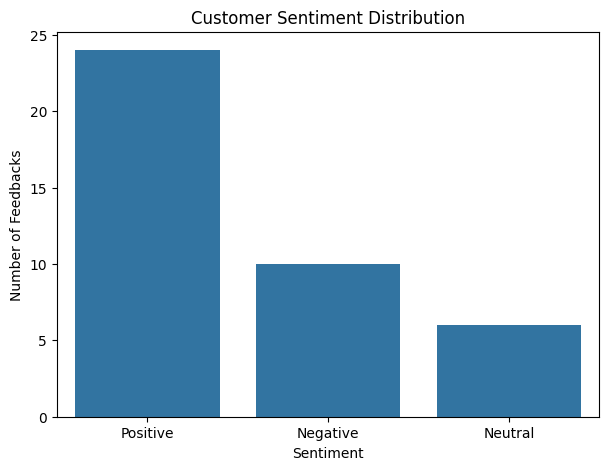

In [16]:
plt.figure(figsize=(7,5))

sns.countplot(data=df, x="Sentiment")

plt.title("Customer Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Feedbacks")

plt.show()

In [17]:
category_counts = df["Category"].value_counts()

print(category_counts)

Category
Product Quality    15
Usability           9
Pricing             8
Packaging           8
Name: count, dtype: int64


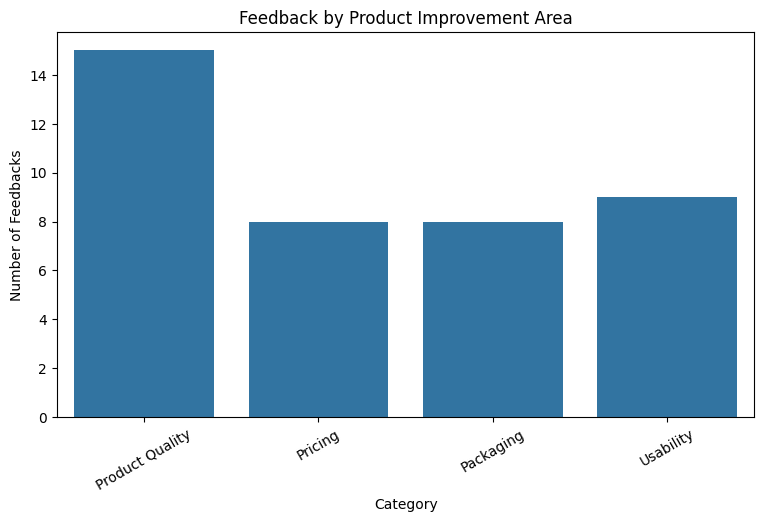

In [18]:
plt.figure(figsize=(9,5))

sns.countplot(data=df, x="Category")

plt.title("Feedback by Product Improvement Area")
plt.xlabel("Category")
plt.ylabel("Number of Feedbacks")

plt.xticks(rotation=30)

plt.show()

In [19]:
negative_feedback = df[df["Sentiment"] == "Negative"]

negative_category = negative_feedback["Category"].value_counts()

print("Negative Feedback by Category:")
print(negative_category)

Negative Feedback by Category:
Category
Product Quality    5
Packaging          2
Pricing            2
Usability          1
Name: count, dtype: int64


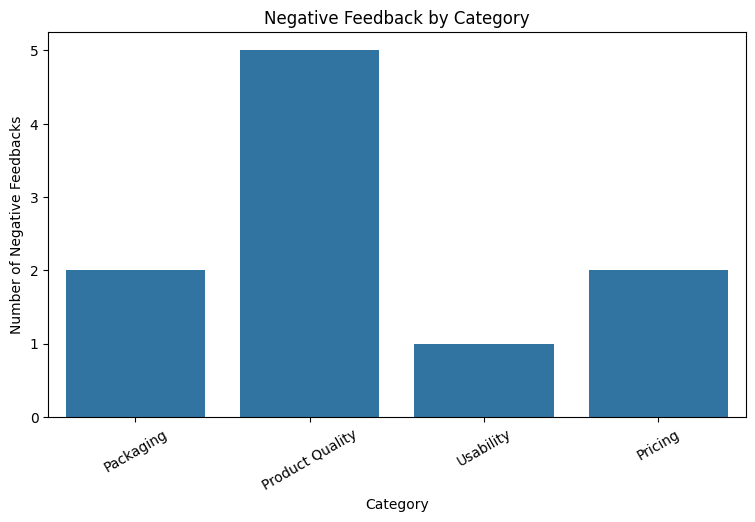

In [20]:
plt.figure(figsize=(9,5))

sns.countplot(
    data=negative_feedback,
    x="Category"
)

plt.title("Negative Feedback by Category")
plt.xlabel("Category")
plt.ylabel("Number of Negative Feedbacks")

plt.xticks(rotation=30)

plt.show()

In [21]:
negative_feedback[
    ["Product", "Feedback", "Rating", "Category"]
].sort_values("Rating")

,Product,Feedback,Rating,Category
24,Power Bank,Charging stops randomly after a few minutes.,1,Product Quality
2,Wireless Headphones,The packaging was damaged when I received the ...,2,Packaging
8,Smart Watch,The instructions are confusing and difficult t...,2,Usability
4,Wireless Headphones,The audio is poor and there is too much backgr...,2,Product Quality
14,Bluetooth Speaker,The sound becomes distorted at high volume.,2,Product Quality
19,Laptop Bag,The zipper quality is disappointing.,2,Product Quality
21,Power Bank,The power bank is too costly for its capacity.,2,Pricing
12,Bluetooth Speaker,The box was badly damaged during delivery.,2,Packaging
34,USB Keyboard,Some keys stopped working after a few weeks.,2,Product Quality
16,Laptop Bag,The bag is useful but the price could be lower.,3,Pricing


In [22]:
product_rating = df.groupby("Product")["Rating"].mean().sort_values(ascending=False)

print(product_rating)

Product
Fitness Band           4.2
Laptop Bag             4.0
Wireless Mouse         4.0
USB Keyboard           4.0
Smart Watch            3.6
Power Bank             3.6
Bluetooth Speaker      3.4
Wireless Headphones    3.4
Name: Rating, dtype: float64


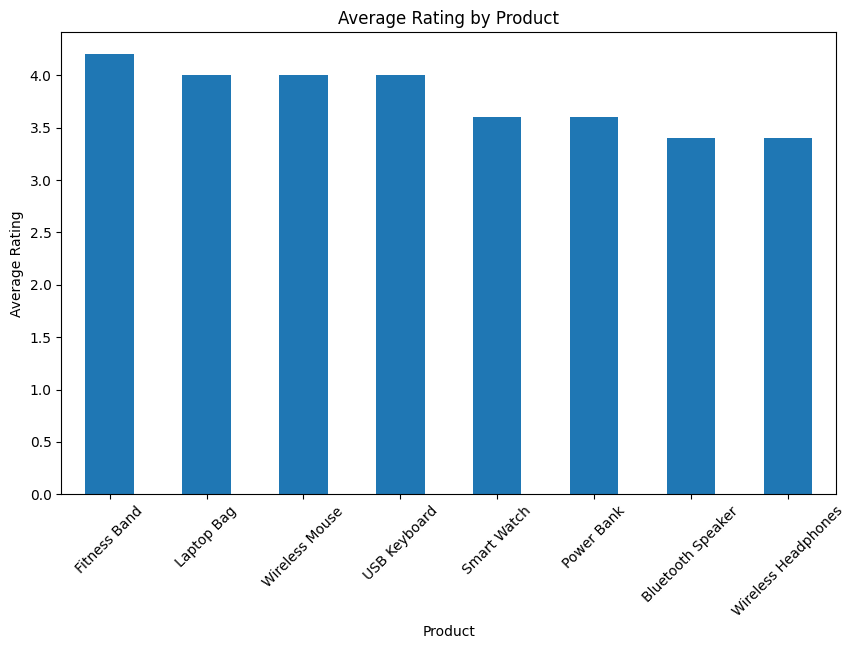

In [23]:
plt.figure(figsize=(10,6))

product_rating.plot(kind="bar")

plt.title("Average Rating by Product")
plt.xlabel("Product")
plt.ylabel("Average Rating")

plt.xticks(rotation=45)

plt.show()

In [24]:
product_sentiment = pd.crosstab(
    df["Product"],
    df["Sentiment"]
)

print(product_sentiment)

Sentiment            Negative  Neutral  Positive
Product                                         
Bluetooth Speaker           2        2         1
Fitness Band                0        0         5
Laptop Bag                  2        0         3
Power Bank                  2        0         3
Smart Watch                 1        1         3
USB Keyboard                1        1         3
Wireless Headphones         2        0         3
Wireless Mouse              0        2         3


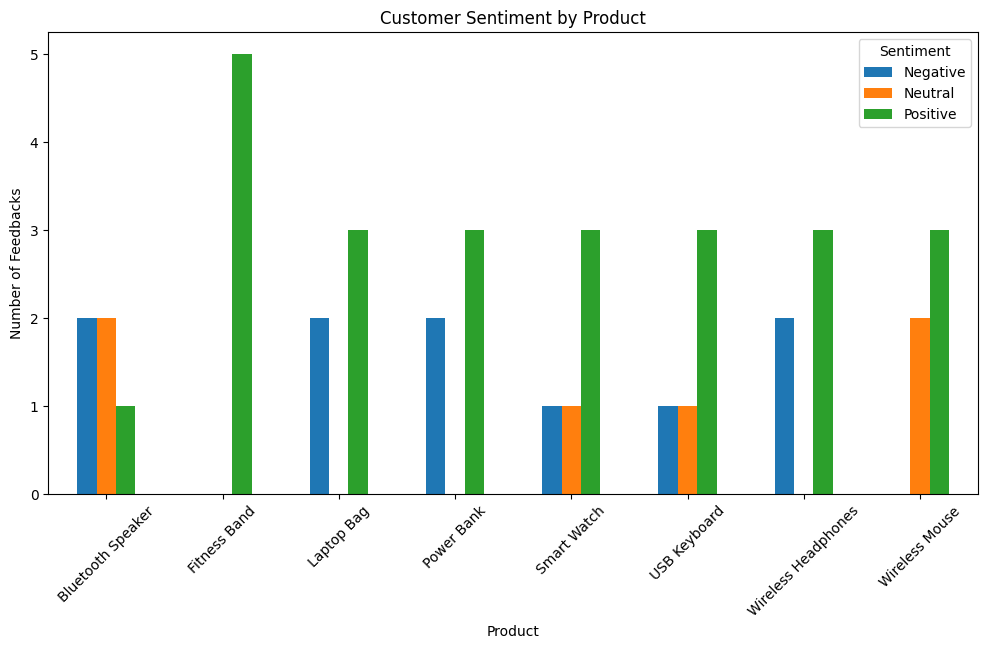

In [25]:
product_sentiment.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Customer Sentiment by Product")
plt.xlabel("Product")
plt.ylabel("Number of Feedbacks")

plt.xticks(rotation=45)

plt.show()

In [26]:
total_feedback = len(df)

positive_feedback = len(
    df[df["Sentiment"] == "Positive"]
)

negative_feedback_count = len(
    df[df["Sentiment"] == "Negative"]
)

neutral_feedback = len(
    df[df["Sentiment"] == "Neutral"]
)

average_rating = df["Rating"].mean()

print("===== BUSINESS INSIGHTS =====")

print("Total Feedback:", total_feedback)
print("Positive Feedback:", positive_feedback)
print("Negative Feedback:", negative_feedback_count)
print("Neutral Feedback:", neutral_feedback)
print("Average Rating:", round(average_rating, 2))

===== BUSINESS INSIGHTS =====
Total Feedback: 40
Positive Feedback: 24
Negative Feedback: 10
Neutral Feedback: 6
Average Rating: 3.78


In [27]:
best_product = (
    df.groupby("Product")["Rating"]
    .mean()
    .idxmax()
)

best_rating = (
    df.groupby("Product")["Rating"]
    .mean()
    .max()
)

print("Best Rated Product:", best_product)
print("Average Rating:", round(best_rating, 2))

Best Rated Product: Fitness Band
Average Rating: 4.2


In [28]:
worst_product = (
    df.groupby("Product")["Rating"]
    .mean()
    .idxmin()
)

worst_rating = (
    df.groupby("Product")["Rating"]
    .mean()
    .min()
)

print("Product Needing Improvement:", worst_product)
print("Average Rating:", round(worst_rating, 2))

Product Needing Improvement: Bluetooth Speaker
Average Rating: 3.4


In [29]:
most_common_issue = negative_feedback["Category"].value_counts().idxmax()

issue_count = negative_feedback["Category"].value_counts().max()

print("Most Common Improvement Area:", most_common_issue)
print("Number of Negative Feedbacks:", issue_count)

Most Common Improvement Area: Product Quality
Number of Negative Feedbacks: 5


In [30]:
print("\n1. DATASET")
print("Total customer feedback:", total_feedback)

print("\n2. SENTIMENT ANALYSIS")
print("Positive:", positive_feedback)
print("Negative:", negative_feedback_count)
print("Neutral:", neutral_feedback)

print("\n3. PRODUCT PERFORMANCE")
print("Best rated product:", best_product)
print("Best average rating:", round(best_rating, 2))

print("\nProduct needing improvement:", worst_product)
print("Lowest average rating:", round(worst_rating, 2))

print("\n4. IMPROVEMENT AREA")
print("Most common negative feedback area:", most_common_issue)

print("\n5. OVERALL RATING")
print("Average customer rating:", round(average_rating, 2))


1. DATASET
Total customer feedback: 40

2. SENTIMENT ANALYSIS
Positive: 24
Negative: 10
Neutral: 6

3. PRODUCT PERFORMANCE
Best rated product: Fitness Band
Best average rating: 4.2

Product needing improvement: Bluetooth Speaker
Lowest average rating: 3.4

4. IMPROVEMENT AREA
Most common negative feedback area: Product Quality

5. OVERALL RATING
Average customer rating: 3.78
